# Задача про рюкзак (0/1 Knapsack) — метод повного перебору (Brute-force)

## Умова
Рюкзак вміщує максимум **50** одиниць ваги. Є 3 предмети:

| Предмет | Вага | Вартість |
|---------|------|----------|
| 1       | 10   | 60       |
| 2       | 20   | 100      |
| 3       | 30   | 120      |

**Мета:** обрати набір предметів так, щоб сумарна вага не перевищувала 50, а сумарна вартість була максимальною.

## Суть методу повного перебору (Brute-force)

Повний перебір — це найпростіша стратегія: ми **розглядаємо всі можливі варіанти** розв’язку, перевіряємо кожен на допустимість і обираємо найкращий.

Для рюкзака кожен предмет може бути або **взятий**, або **не взятий** — тобто 2 стани на предмет. Якщо предметів `n`, то всіх можливих комбінацій (підмножин):

**2ⁿ**

Для нашої задачі: 2³ = **8 комбінацій**. Алгоритм:
1. Згенерувати всі 2ⁿ підмножин предметів.
2. Для кожної порахувати сумарну вагу та вартість.
3. Відкинути ті, де вага > місткості рюкзака.
4. Серед допустимих обрати ту, де вартість найбільша.

## Усі комбінації для нашої задачі

| Комбінація       | Вага | Вартість | Влазить? |
|------------------|------|----------|----------|
| { }              | 0    | 0        | ✅       |
| { П1 }           | 10   | 60       | ✅       |
| { П2 }           | 20   | 100      | ✅       |
| { П3 }           | 30   | 120      | ✅       |
| { П1, П2 }       | 30   | 160      | ✅       |
| { П1, П3 }       | 40   | 180      | ✅       |
| **{ П2, П3 }**   | **50** | **220**| ✅ **← максимум** |
| { П1, П2, П3 }   | 60   | 280      | ❌ (60 > 50) |

**Відповідь:** беремо предмети **2 і 3** → вага 50, вартість **220**.

## Переваги та недоліки

### Переваги
- **Простота.** Логіка очевидна, легко зрозуміти й реалізувати.
- **Гарантований результат.** Оскільки перевіряються абсолютно всі варіанти, відповідь завжди оптимальна (точна, а не наближена).
- **Універсальність.** Підходить майже для будь-якої задачі, де можна перелічити варіанти.

### Недоліки
- **Експоненційна складність — O(2ⁿ).** Кількість комбінацій подвоюється з кожним новим предметом: 10 предметів → 1024 варіанти, 30 предметів → понад мільярд, 50 → астрономічне число.
- **Непридатний для великих вхідних даних.** Уже при кількох десятках предметів обчислення стають неможливими за розумний час.
- **Неефективність.** Багато варіантів перераховуються «з нуля», хоча є спільні підзадачі (саме це й виправляє динамічне програмування).

In [ ]:
# Функція для обчислення максимальної вартості
def knapSack(W, wt, val, n):
    # Базовий випадок
    if n == 0 or W == 0:
        return 0

    # Якщо вага n-го предмета більше, ніж місткість рюкзака, то цей предмет не можна включити у рюкзак
    if wt[n - 1] > W:
        return knapSack(W, wt, val, n - 1)

    # повертаємо максимум із двох випадків:
    # (1) n-ий предмет включено
    # (2) не включено
    else:
        return max(
            val[n - 1] + knapSack(W - wt[n - 1], wt, val, n - 1),
            knapSack(W, wt, val, n - 1),
        )

# ваги та вартість предметів
value = [60, 100, 120]
weight = [10, 20, 30]
# місткість рюкзака
capacity = 50
# кількість предметів
n = len(value)
# викликаємо функцію
print(knapSack(capacity, weight, value, n))  # 220


220


## Пояснення коду (рядок за рядком)

**`def knapSack(W, wt, val, n):`**
Функція приймає:
- `W` — поточну вільну місткість,
- `wt` — список ваг,
- `val` — список вартостей,
- `n` — скільки предметів ще розглядаємо.

**`if n == 0 or W == 0: return 0`**
Базовий (зупиняючий) випадок рекурсії. Якщо предметів не залишилось (`n == 0`) або місткість вичерпана (`W == 0`), додати більше нічого — повертаємо вартість 0.
___

**`if wt[n - 1] > W:`**


Дивимось на поточний предмет (його індекс `n - 1`, бо нумерація з 0). Якщо його вага більша за вільну місткість — взяти його **неможливо**. Тому просто переходимо до решти предметів: `knapSack(W, wt, val, n - 1)`.

**`else:` → `max(...)`**

### Гілка `else:` → `max(...)` — детально

Сюди код потрапляє тоді, коли предмет **вміщається** у рюкзак (`wt[n - 1] <= W`). У задачі 0/1 з кожним предметом можна зробити лише **дві речі**: взяти його повністю або не брати зовсім. Тому ми чесно рахуємо **обидва** сценарії й залишаємо той, що дає більшу вартість, — за це й відповідає `max(...)`.

#### Що означає кожен рядок

**Варіант 1 — взяти предмет** `val[n - 1] + knapSack(W - wt[n - 1], wt, val, n - 1)`
- `val[n - 1]` — одразу «зараховуємо» вартість цього предмета.
- `W - wt[n - 1]` — місткість **зменшується** на вагу предмета (місце вже зайняте).
- `n - 1` — переходимо до решти предметів.

**Варіант 2 — не брати предмет** `knapSack(W, wt, val, n - 1)`
- вартість предмета **не додаємо** (0);
- `W` — місткість лишається **без змін** (місце вільне);
- `n - 1` — так само переходимо до решти предметів.

#### Що змінюється у двох варіантах

| Дія            | Накопичена вартість | Місткість `W`     | Предмети `n` |
|----------------|---------------------|-------------------|--------------|
| Взяти предмет  | `+ val[n - 1]`      | `W - wt[n - 1]`   | `n → n - 1`  |
| Не брати       | `+ 0`               | `W` (без змін)    | `n → n - 1`  |

> **Чому `n - 1` в обох випадках?** Рішення щодо `n`-го предмета вже **прийняте** (взяли або ні), і ми до нього більше не повертаємось. В обох гілках лишається та сама менша підзадача — «найкраще для перших `n - 1` предметів». Відрізняються гілки лише **місткістю** та **вже накопиченою вартістю**. Саме це розгалуження «взяти / не брати» на кожному предметі й породжує всі 2ⁿ комбінацій.

#### Конкретний приклад

Виклик `knapSack(W=50, n=3)`, поточний предмет — **П3** (вага 30, вартість 120):

- **Взяти П3:** `120 + knapSack(20, ..., 2)` — забираємо 120, місткість падає до `50 - 30 = 20`, далі шукаємо найкраще для П1–П2 при місткості 20. Результат: `120 + 100 = 220`.
- **Не брати П3:** `knapSack(50, ..., 2)` — нічого не додаємо, місткість лишається 50, шукаємо найкраще для П1–П2 при місткості 50. Результат: `160`.

`max(220, 160) = 220` → вигідніше **взяти П3** (у парі з П2).

## Як працює логіка повного перебору (детально)

Уся складність методу — в одній ідеї, яка далі просто повторюється.

Для **кожного** предмета функція ставить рівно одне питання: **взяти його чи ні?** Дві відповіді — дві гілки. Функція не вгадує, що вигідніше: вона рахує **обидва** варіанти й лишає більший (`max`).

- 3 предмети → 2 × 2 × 2 = **8** можливих наборів;
- `n` предметів → **2ⁿ** наборів.

Саме тому в коді гілка `else` має `max(...)` з двох рекурсивних викликів — це «спробувати взяти» та «спробувати не брати».

## Крок 1: одне рішення (гілка `else`)

Розгляньмо найперший виклик. Поточний предмет — третій (вага 30, вартість 120):

```
knapSack(W=50, n=3)   ← вирішуємо предмет 3 (вага 30, вартість 120)
│
├─ ВЗЯТИ П3:     +120 вартості, місце 50 → 20   →  knapSack(W=20, n=2)
│
└─ НЕ БРАТИ П3:  нічого не додаємо, місце 50     →  knapSack(W=50, n=2)

відповідь вузла = max( 120 + knapSack(20, 2) ,  knapSack(50, 2) )
```

Що відбувається у двох гілках:

- **Взяти предмет** — `val[n-1] + knapSack(W - wt[n-1], ...)`: одразу зараховуємо вартість (+120) і зменшуємо вільне місце (50 → 20).
- **Не брати** — `knapSack(W, ...)`: вартість не додаємо, місце лишається (50).

У **обох** гілках кількість предметів зменшується на один (`n`: 3 → 2). Саме це поступове зменшення доводить рекурсію до базового випадку й зупиняє її.

## Крок 2: повне дерево рекурсії

Те саме питання повторюється для предмета 2, потім для предмета 1 — гілки подвоюються, виходить дерево. Кожен **рівень** вирішує долю одного предмета: корінь — П3, середній — П2, нижній — П1.

```
knapSack(50, 3)
│
├─ взяти П3 (+120) ─→ knapSack(20, 2) = 100
│  ├─ взяти П2 (+100) ─→ knapSack(0, 1)  = 0     (база: W=0)
│  └─ не брати П2      ─→ knapSack(20, 1) = 60
│     max(100, 60) = 100;  «взяти П3»: 120 + 100 = 220   ★ оптимум
│
└─ не брати П3 ───→ knapSack(50, 2) = 160
   ├─ взяти П2 (+100) ─→ knapSack(30, 1) = 60
   └─ не брати П2      ─→ knapSack(50, 1) = 60
      max(160, 60) = 160

КОРІНЬ:  max(220, 160) = 220  →  беремо П3 і П2 (вага 50, вартість 220)
```

Як читати дерево:

- у кожному вузлі написано, скільки максимум вартості дає ця підзадача (`knapSack(50, 2) = 160` — «найкраще для предметів 1–2 при місткості 50»);
- вартість набирається на гілках «взяти» (+120, +100), а не у вузлах-листках;
- тому оптимальний шлях ★: листок дає 0 → беремо П2 (+100) → 100 → беремо П3 (+120) → **220**.

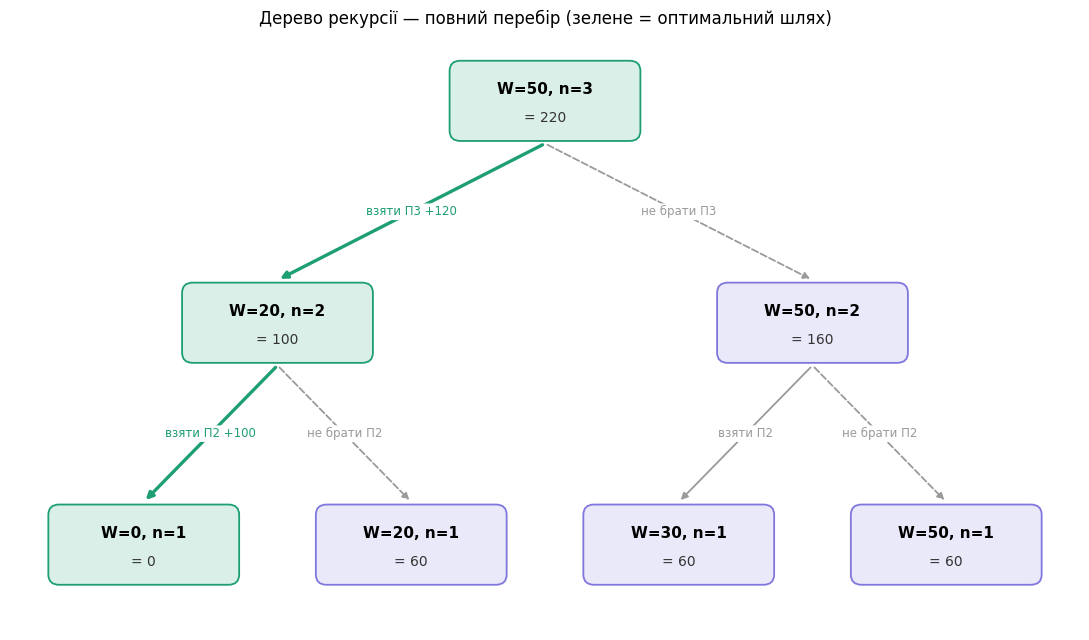

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgba

# координати вузлів (x, y)
pos = {
    'root': (6.0, 7.2),
    'L':    (3.0, 4.6),  'R':  (9.0, 4.6),
    'l1':   (1.5, 2.0),  'l2': (4.5, 2.0),
    'l3':   (7.5, 2.0),  'l4': (10.5, 2.0),
}

# підпис вузла: (рядок1, рядок2, колір)  — зелений = оптимальний шлях, фіолетовий = решта
label = {
    'root': ('W=50, n=3', '= 220', '#1D9E75'),
    'L':    ('W=20, n=2', '= 100', '#1D9E75'),
    'R':    ('W=50, n=2', '= 160', '#7F77DD'),
    'l1':   ('W=0, n=1',  '= 0',   '#1D9E75'),
    'l2':   ('W=20, n=1', '= 60',  '#7F77DD'),
    'l3':   ('W=30, n=1', '= 60',  '#7F77DD'),
    'l4':   ('W=50, n=1', '= 60',  '#7F77DD'),
}

# ребра: (від, до, стиль_лінії, колір, підпис)
edges = [
    ('root', 'L', '-',  '#1D9E75', 'взяти П3 +120'),
    ('root', 'R', '--', '#9a9a9a', 'не брати П3'),
    ('L', 'l1', '-',  '#1D9E75', 'взяти П2 +100'),
    ('L', 'l2', '--', '#9a9a9a', 'не брати П2'),
    ('R', 'l3', '-',  '#9a9a9a', 'взяти П2'),
    ('R', 'l4', '--', '#9a9a9a', 'не брати П2'),
]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 12); ax.set_ylim(1, 8); ax.axis('off')

# спершу ребра (щоб лінії були під вузлами)
for a, b, ls, col, txt in edges:
    x1, y1 = pos[a][0], pos[a][1] - 0.5
    x2, y2 = pos[b][0], pos[b][1] + 0.5
    lw = 2.4 if col == '#1D9E75' else 1.3
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=col, lw=lw, linestyle=ls))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, txt, fontsize=8.5, color=col,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'))

# потім вузли
for key, (x, y) in pos.items():
    title, val, col = label[key]
    ax.add_patch(FancyBboxPatch((x - 1.05, y - 0.45), 2.1, 0.9,
                                boxstyle='round,pad=0.02,rounding_size=0.12',
                                linewidth=1.3, edgecolor=col, facecolor=to_rgba(col, 0.16)))
    ax.text(x, y + 0.13, title, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(x, y - 0.2, val, ha='center', va='center', fontsize=10, color='#333333')

ax.set_title('Дерево рекурсії — повний перебір (зелене = оптимальний шлях)', fontsize=12)
plt.tight_layout()
plt.show()

## Порядок виконання коду (трасування)

Python обчислює перший аргумент `max(...)` раніше за другий, тому функція завжди спершу пробує гілку «взяти», спускається вглиб до базового випадку, а потім рахує `max` на зворотному шляху:

1. `knapSack(50, 3)` — предмет 3 вміщається, тож рахуємо `max(взяти, не брати)`. Спершу — «взяти».
2. Взяли П3 (+120) → спускаємось у `knapSack(20, 2)`.
3. Предмет 2 вміщається. Спершу «взяти П2» (+100) → спускаємось у `knapSack(0, 1)`.
4. `knapSack(0, 1)`: місце скінчилось (W = 0) → базовий випадок → повертає **0**. Гілка «взяти П2» дала 100 + 0 = **100**.
5. Тепер «не брати П2» → `knapSack(20, 1)` повертає 60. Підсумок вузла: `max(100, 60) = 100`.
6. Повертаємось у корінь: гілка «взяти П3» = 120 + 100 = **220**.
7. Тепер «не брати П3» → `knapSack(50, 2) = 160` (права частина дерева).
8. Корінь: `max(220, 160) = 220` — відповідь. У рюкзаку опиняються предмети 3 і 2.

## Чому це «повний перебір» і чому він повільний

Жодна гілка дерева не пропускається — функція перевіряє **геть усі** комбінації (тут 8). Через це метод і називають повним перебором.

Але кожен новий предмет **подвоює** кількість гілок: складність — **O(2ⁿ)**. 3 предмети → 8 гілок, 20 → понад мільйон, 30 → понад мільярд. Тому для великих задач переходять до динамічного програмування (O(n·W)).

In [ ]:
from itertools import combinations

def knapsack_brute_force(W, wt, val):
    n = len(val)
    best_value = 0
    best_combo = ()

    # перебираємо всі можливі підмножини предметів (2^n штук)
    for r in range(n + 1):
        for combo in combinations(range(n), r):
            total_weight = sum(wt[i] for i in combo)
            total_value = sum(val[i] for i in combo)
            # враховуємо лише ті, що влазять у рюкзак
            if total_weight <= W and total_value > best_value:
                best_value = total_value
                best_combo = combo

    return best_value, best_combo

value = [60, 100, 120]
weight = [10, 20, 30]
capacity = 50

best_value, best_combo = knapsack_brute_force(capacity, weight, value)
print("Максимальна вартість:", best_value)            # 220
print("Обрані предмети (індекси):", best_combo)        # (1, 2) -> предмети 2 і 3

Максимальна вартість: 220
Обрані предмети (індекси): (1, 2)


## Висновок

- Обидва варіанти (рекурсивний і явний перебір) дають однакову відповідь: **220**.
- Оптимальний набір — **предмети 2 і 3** (вага 20 + 30 = 50, вартість 100 + 120 = 220).
- Метод повного перебору **гарантує точний результат**, але має складність **O(2ⁿ)** і не масштабується.
- Наступний крок для тієї ж задачі — **динамічне програмування**, яке дає ту саму відповідь набагато швидше (O(n·W)).

_________________________________________________________________________
# Задача про рюкзак — жадібний метод (Greedy)

## Суть методу
Жадібний алгоритм на кожному кроці робить вибір, який **здається найкращим саме зараз**, не переглядаючи всі варіанти наперед.

Для рюкзака типова жадібна стратегія така:
1. Для кожного предмета порахувати «питому цінність» = **вартість / вага**.
2. Відсортувати предмети за цим співвідношенням від більшого до меншого.
3. Йти по списку й брати предмет, якщо він ще вміщається у рюкзак.

> ⚠️ **Важливо.** Для задачі **0/1** (предмет беремо повністю або не беремо зовсім) жадібний метод **не гарантує оптимальний результат**. Він оптимальний лише для **дробової** задачі (коли предмет можна брати частинами).

In [ ]:
class Item:
    def __init__(self, weight, value):
        self.weight = weight
        self.value = value
        self.ratio = value / weight

def knapSack(items: list[Item], capacity: int) -> int:
    items.sort(key=lambda x: x.ratio, reverse=True)
    total_value = 0
    for item in items:
        if capacity >= item.weight:
            capacity -= item.weight
            total_value += item.value
    return total_value

# Дані предметів
items = [Item(10, 60), Item(20, 100), Item(30, 120)]
# Місткість рюкзака
capacity = 50
# Виклик функції
print(knapSack(items, capacity))  # 160


160


## Пояснення коду (жадібний метод)

### Клас `Item` — один предмет
- `__init__(self, weight, value)` — конструктор: кожен предмет зберігає свою вагу й вартість.
- `self.ratio = value / weight` — одразу рахуємо «питому цінність» (вартість на одиницю ваги). Саме за нею жадібний метод обиратиме предмети.

### Функція `knapSack(items, capacity)`
- `items.sort(key=lambda x: x.ratio, reverse=True)` — сортуємо предмети за `ratio` від більшого до меншого (`reverse=True`): спочатку найвигідніші «за грам».
- `total_value = 0` — лічильник зібраної вартості.
- `for item in items:` — проходимо предмети у відсортованому порядку.
- `if capacity >= item.weight:` — якщо предмет ще вміщається у вільне місце…
  - `capacity -= item.weight` — …беремо його: зменшуємо вільне місце на його вагу;
  - `total_value += item.value` — …додаємо його вартість.
- Якщо не вміщається — предмет просто пропускається (у задачі 0/1 частину взяти не можна).
- `return total_value` — підсумкова зібрана вартість.

### Хід на твоїх даних
Відношення: П1 = 6.0, П2 = 5.0, П3 = 4.0 → порядок не змінюється.
- беремо П1 (вага 10) → місце 40, вартість 60;
- беремо П2 (вага 20) → місце 20, вартість 160;
- П3 (вага 30) не вміщається у 20 → пропускаємо.

Результат: **160**.

def knapsack_greedy(items, capacity):
    # items — список кортежів (вага, вартість)
    # сортуємо за відношенням вартість/вага, від більшого до меншого
    # (sorted, а не .sort — щоб не міняти порядок вхідного списку)
    items = sorted(items, key=lambda it: it[1] / it[0], reverse=True)

    total_value = 0
    for weight, value in items:
        if capacity >= weight:
            capacity -= weight
            total_value += value
    return total_value

# Дані предметів: (вага, вартість)
items = [(10, 60), (20, 100), (30, 120)]
capacity = 50
print(knapsack_greedy(items, capacity))  # 160


## Як працює жадібний метод (покроково)

Жадібний підхід — проста лінійна процедура: порахувати «вигідність» кожного предмета, відсортувати за нею й брати по черзі, поки вміщається.

1. Для кожного предмета рахуємо `ratio = вартість / вага`.
2. Сортуємо предмети за `ratio` від більшого до меншого.
3. Ідемо по списку й беремо предмет, якщо він ще вміщається у вільне місце.

```
Сортуємо за ratio (вартість/вага) і беремо по черзі, поки вміщається:

  П1: вага 10, варт. 60,  ratio 6.0  →  взято    (вільно 50 → 40)
  П2: вага 20, варт. 100, ratio 5.0  →  взято    (вільно 40 → 20)
  П3: вага 30, варт. 120, ratio 4.0  →  пропуск   (треба 30 > вільно 20)

  Разом: вартість 160, вага 30 з 50
```

Жадібний завжди хапає найвигідніший «за грам» предмет, що ще влазить, і ніколи не передумує.

## Чому жадібний програє (для задачі 0/1)

Жадібний спокусився на маленький П1 з найбільшим `ratio` — і через це не зміг узяти важкий П3. Порівняймо заповнення рюкзака:

```
Шкала = місткість 50.

Жадібний → 160:
  [  П1: 10  ][     П2: 20     ][   порожньо: 20   ]
  зайнято 30 / 50   (20 одиниць змарновано)

Оптимум → 220:
  [     П2: 20     ][        П3: 30        ]
  зайнято 50 / 50   (рюкзак повний)
```

Жадібний дивиться лише на вигідність поточного предмета й не помічає, що відмова від П1 звільнила б місце під значно ціннішу пару {П2, П3}. Тому він швидкий (O(n·log n)), але оптимум не гарантує.

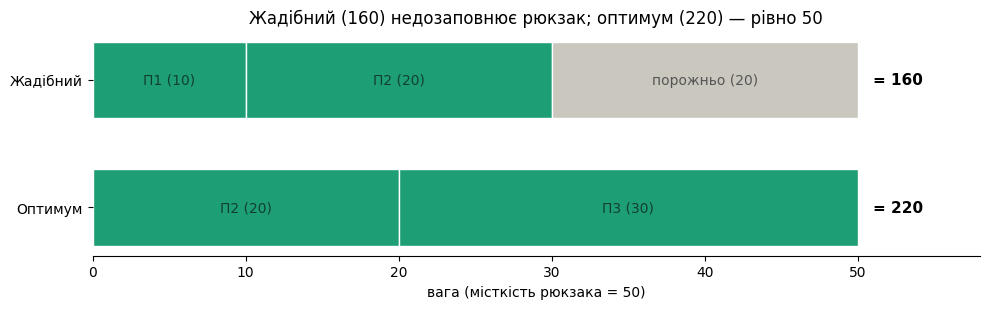

In [ ]:
import matplotlib.pyplot as plt

teal = '#1D9E75'   # предмет у рюкзаку
gray = '#C9C7BE'   # порожнє місце

fig, ax = plt.subplots(figsize=(10, 3.2))

# горизонтальна смуга зі стрічок-сегментів
def bar(y, segments):
    left = 0
    for width, color, lbl in segments:
        ax.barh(y, width, left=left, height=0.6, color=color, edgecolor='white')
        ax.text(left + width / 2, y, lbl, ha='center', va='center',
                fontsize=10, color='#11402f' if color == teal else '#555555')
        left += width

# Жадібний: П1(10) + П2(20) + порожньо(20)  → 160
bar(1, [(10, teal, 'П1 (10)'), (20, teal, 'П2 (20)'), (20, gray, 'порожньо (20)')])
# Оптимум:  П2(20) + П3(30)                 → 220
bar(0, [(20, teal, 'П2 (20)'), (30, teal, 'П3 (30)')])

ax.text(51, 1, '= 160', va='center', fontsize=11, fontweight='bold')
ax.text(51, 0, '= 220', va='center', fontsize=11, fontweight='bold')

ax.set_yticks([1, 0])
ax.set_yticklabels(['Жадібний', 'Оптимум'])
ax.set_xlim(0, 58)
ax.set_xlabel('вага (місткість рюкзака = 50)')
ax.set_title('Жадібний (160) недозаповнює рюкзак; оптимум (220) — рівно 50')
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## Пояснення коду та покрокове рішення

**Крок 1. Питома цінність (вартість / вага):**

| Предмет | Вага | Вартість | Співвідношення |
|---------|------|----------|----------------|
| 1       | 10   | 60       | **6.0**        |
| 2       | 20   | 100      | **5.0**        |
| 3       | 30   | 120      | **4.0**        |

**Крок 2. Сортуємо за спаданням:** П1 (6.0) → П2 (5.0) → П3 (4.0).

**Крок 3. Жадібно беремо предмети:**
- Беремо **П1**: вага 10 ≤ 50 ✅ → вага = 10, вартість = 60
- Беремо **П2**: 10 + 20 = 30 ≤ 50 ✅ → вага = 30, вартість = 160
- **П3**: 30 + 30 = 60 > 50 ❌ → пропускаємо

**Результат жадібного методу:** предмети {1, 2}, вартість **160**.

> ❗ **Порівняння з оптимумом.** Точна відповідь (брутфорс / ДП) = **220** (предмети 2 і 3). Жадібний метод дав лише **160**. Він «спокусився» на предмет 1 з найбільшим співвідношенням, але через це не зміг взяти кращу пару 2+3, яка ідеально заповнює рюкзак (вага рівно 50).


## Переваги та недоліки жадібного методу

### Переваги
- **Дуже швидкий.** Складність ≈ **O(n·log n)** (основний час — це сортування).
- **Мало пам’яті.** Не потребує таблиць чи рекурсивного дерева.
- **Простий** в реалізації та розумінні.

### Недоліки
- **Не гарантує оптимум для задачі 0/1** — може дати гіршу відповідь (як тут: 160 замість 220).
- **Залежить від «локального» вибору** і не вміє переглядати рішення назад.
- Оптимальний лише для **дробової** задачі про рюкзак.

In [ ]:
def knapSack(W, wt, val, n):
    # створюємо таблицю K для зберігання оптимальних значень підзадач
    K = [[0 for w in range(W + 1)] for i in range(n + 1)]

    # будуємо таблицю K знизу вгору
    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                K[i][w] = 0
            elif wt[i - 1] <= w:
                K[i][w] = max(val[i - 1] + K[i - 1][w - wt[i - 1]], K[i - 1][w])
            else:
                K[i][w] = K[i - 1][w]

    return K[n][W]

# ваги та вартість предметів
value = [60, 100, 120]
weight = [10, 20, 30]
# місткість рюкзака
capacity = 50
# кількість предметів
n = len(value)
# виклик функції
print(knapSack(capacity, weight, value, n))  # 220


220


## Суть динамічного програмування (DP)

Ідея: розбити задачу на менші підзадачі, розв'язати кожну **лише раз** і зберегти результати в таблиці, щоб не рахувати повторно.

Будуємо таблицю `K`, де **`K[i][w]`** — максимальна вартість, яку можна зібрати, маючи **перші `i` предметів** і місткість **`w`**. Таблицю заповнюємо знизу вгору: від простих підзадач (0 предметів, місткість 0) до повної відповіді `K[n][W]`.

## Пояснення коду (рядок за рядком)

- `K = [[0 ...] for i in range(n + 1)]` — таблиця з `n+1` рядків (0…n предметів) і `W+1` стовпців (місткість 0…W), заповнена нулями.
- Два цикли `for i ... for w ...` проходять усі підзадачі (кожен предмет × кожну місткість).
- `if i == 0 or w == 0:` → `K[i][w] = 0` — без предметів або без місця вартість нульова (базові випадки: верхній рядок і лівий стовпець).
- `elif wt[i-1] <= w:` — поточний предмет вміщається, тож беремо кращий із двох варіантів:
  - `val[i-1] + K[i-1][w - wt[i-1]]` — **взяти**: його вартість + найкраще рішення для залишку місткості з попередніх предметів;
  - `K[i-1][w]` — **не брати**: переносимо значення з рядка вище.
- `else:` → `K[i][w] = K[i-1][w]` — предмет не вміщається, переносимо значення зверху.
- `return K[n][W]` — у правому нижньому куті лежить відповідь.

> Чому `i-1` як індекс: `i` — це *кількість* предметів у розгляді, а списки `wt`/`val` індексуються з 0, тож `i`-й предмет має індекс `i-1`.

# Задача про рюкзак — динамічне програмування (DP)

## Суть методу
Динамічне програмування розбиває задачу на менші підзадачі, розв’язує кожну **один раз** і зберігає результати у таблиці, щоб не рахувати їх повторно.

Будуємо таблицю `dp`, де **`dp[i][w]`** = максимальна вартість, яку можна зібрати, використовуючи **перші `i` предметів** при місткості **`w`**.

**Формула переходу** для кожного предмета `i` та місткості `w`:
- Якщо предмет не вміщається (`wt[i-1] > w`): `dp[i][w] = dp[i-1][w]` (переносимо значення зверху).
- Інакше беремо краще з двох: `dp[i][w] = max( dp[i-1][w],  val[i-1] + dp[i-1][w - wt[i-1]] )`
  - перший варіант — **не брати** предмет,
  - другий — **взяти** предмет (його вартість + найкраще рішення для залишку місткості).

Відповідь — у клітинці **`dp[n][W]`**.

## Чому при «не вміщується» переносимо значення зверху?

**Суть:** якщо предмет не влазить, єдиний можливий хід — не брати його, а це те саме, що готова відповідь для набору на один предмет менший.

Згадаймо, що означає сама комірка:

> **`dp[i][w]`** — найкраща вартість, яку можна зібрати, маючи дозвіл користуватися **лише першими `i` предметами** і місткість `w`.

Коли ми доходимо до предмета `i`, у нас завжди є **рівно два варіанти**: взяти його або не брати. Саме з них `max(...)` обирає кращий.

Але якщо `wt[i-1] > w` (предмет важчий за вільне місце), варіант **«взяти» стає неможливим** — предмет фізично не влізе. Залишається єдиний варіант: **«не брати»**.

А що означає «не брати предмет `i`»? Що набір, з якого ми реально вибираємо, звужується до **перших `i−1` предметів**, а місткість лишається тією самою `w` (ми ж нічого не поклали). І найкраща відповідь для цієї ситуації вже порахована — це **`dp[i−1][w]`**.

Тепер ключове про слово «зверху»:
- рядок `i−1` — це «перші `i−1` предметів» (на один предмет менше);
- той самий стовпець `w` — це «та сама місткість».

Отже клітинка `dp[i−1][w]` стоїть **точно над** `dp[i][w]`. Тому «не брати предмет, що не влазить» = «скопіювати готову відповідь із клітинки згори».

### Це не втрата, а «нічого не змінилось»
Додавання до набору ще одного предмета, яким ми все одно не можемо скористатися, не здатне ні покращити, ні погіршити результат. Тому оптимум лишається таким самим, як на попередньому рядку.

### Це окремий випадок загальної формули
«Перенесення зверху» — не окреме правило, а спрощення `max`:

```
dp[i][w] = max( dp[i-1][w] ,  val + dp[i-1][w - wt] )
                    ▲                     ▲
                 не брати              взяти   ← відпадає, бо предмет не влазить
```

Коли «взяти» неможливо, у `max` лишається тільки перший доданок → `dp[i][w] = dp[i-1][w]`.

### Приклад із нашої таблиці
`dp[2][1]`: предмет П2 важить 2, а місткість лише 1. Оскільки 2 > 1, П2 не влазить. Тоді «найкраще з {П1, П2} при місткості 1» = «найкраще з {П1} при місткості 1» = **6**. Саме це значення стоїть згори, у `dp[1][1]`. Новий предмет не вліз — відповідь не змінилась.

## Суть динамічного програмування

Динамічне програмування (DP) — це спосіб розв'язати складну задачу, розбивши її на менші підзадачі, розв'язавши кожну **лише раз** і **зберігши** результати, щоб не рахувати їх повторно.

**Як працює:**
1. Велику задачу зводимо до менших підзадач того ж типу.
2. Розв'язуємо найпростіші з них (базові випадки).
3. З їхніх відповідей будуємо відповіді для складніших підзадач і записуємо все в таблицю.
4. Коли якась підзадача вже обчислена — просто **підглядаємо** її в таблиці, а не рахуємо знову.

**Коли підходить:** задача має дві властивості —
- *оптимальна підструктура*: розв'язок великої задачі складається з розв'язків менших;
- *підзадачі повторюються*: одні й ті самі менші задачі трапляються багато разів.

**Що дає:** замість рахувати однакові речі заново (як наївна рекурсія з експоненційним часом), DP обчислює кожну підзадачу один раз — і працює набагато швидше.

> У задачі про рюкзак підзадачами були клітинки `K[i][w]`, а «підгляданням» — використання вже заповнених сусідніх клітинок.

In [ ]:
def knapSack(W, wt, val, n):
    # створюємо таблицю K для зберігання оптимальних значень підзадач
    K = [[0 for w in range(W + 1)] for i in range(n + 1)]

    # будуємо таблицю K знизу вгору
    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                K[i][w] = 0
            elif wt[i - 1] <= w:
                K[i][w] = max(val[i - 1] + K[i - 1][w - wt[i - 1]], K[i - 1][w])
            else:
                K[i][w] = K[i - 1][w]

    return K[n][W]

# ваги та вартість предметів
value = [60, 100, 120]
weight = [10, 20, 30]
# місткість рюкзака
capacity = 50
# кількість предметів
n = len(value)
# виклик функції
print(knapSack(capacity, weight, value, n))  # 220


220


## Рекурентна формула і заповнена таблиця

Для кожної клітинки:

```
якщо wt[i-1] > w:   K[i][w] = K[i-1][w]
інакше:             K[i][w] = max( K[i-1][w] ,  val[i-1] + K[i-1][w - wt[i-1]] )
                                   └ не брати ┘   └────────── взяти ──────────┘
```

Заповнена таблиця (показано місткості, кратні 10):

```
 i \ W |  0   10   20   30   40   50
-------+----------------------------
 0 (—) |  0    0    0    0    0    0
 1 +П1 |  0   60   60   60   60   60
 2 +П2 |  0   60  100  160  160  160
 3 +П3 |  0   60  100  160  180  220   ← відповідь
```

`K[2][30] = 160` читається як «найкраще для предметів 1–2 при місткості 30».

## Що означає ця таблиця

Це повна таблиця `K[i][w]`, яку будує код динамічного програмування.

- **Рядки `i`** — скільки предметів дозволено використати: 0 (жодного), 1 (+П1), 2 (+П1, П2), 3 (усі три).
- **Стовпці `w`** — місткість рюкзака від 0 до 50 (тут показано кожне значення, а не лише кратні 10).
- **Клітинка `K[i][w]`** — максимальна вартість, яку можна зібрати з перших `i` предметів за місткості `w`.

Значення в рядку ростуть «сходинками» — саме на тих місткостях, де вже вміщається ще один предмет (або вигідніша їх комбінація). Наприклад, у нижньому рядку (дозволені всі три предмети):

- 0–9 → 0 (нічого не влазить);
- 10–19 → 60 (влазить лише П1);
- 20–29 → 100 (П2);
- 30–39 → 160 (П1 + П2);
- 40–49 → 180 (П1 + П3);
- рівно 50 → **220** (П2 + П3 — для цієї пари потрібно саме 50 одиниць).

Тому між «сходинками» значення не змінюється, і зведена таблиця (стовпці 0, 10, 20, …) показувала ті самі ключові числа.

**Відповідь** — у правому нижньому куті: `K[3][50] = 220`.

## Ідея динамічного програмування — найпростіше

Уяви, що ти заповнюєш **шпаргалку** (таблицю), де кожна клітинка відповідає на одне маленьке питання:

> «Яку найбільшу вартість я зберу, якщо дозволено брати **тільки перші `i` предметів**, а рюкзак вміщає **`w` одиниць**?»

Сенс — не розв'язувати велике питання одразу, а заповнювати шпаргалку від найлегших питань до найскладнішого:

1. **Найлегші випадки.** Якщо предметів нема (`i = 0`) або місця нема (`w = 0`) — відповідь завжди **0**. Це верхній рядок і лівий стовпець таблиці.
2. **Додаємо предмети по одному.** Для кожного нового предмета проходимо всі можливі розміри рюкзака і ставимо одне питання: **взяти цей предмет чи ні?**
   - **Не брати:** відповідь така сама, як без нього → дивимось у клітинку **прямо над** поточною.
   - **Взяти:** додаємо його вартість + найкраще, що влізе в **залишок місця**. А це вже записано в шпаргалці (рядок вище, стовпець «лівіше» рівно на вагу предмета).
   - Лишаємо **більше** з двох чисел.
3. Дійшли до останнього предмета й повної місткості → відповідь сидить у **правому нижньому куті**.

**У чому весь фокус:** повний перебір щоразу рахує ті самі під-питання заново (тому повільний). Динамічне програмування рахує кожне під-питання **лише раз**, записує відповідь у таблицю — і далі просто **підглядає**, а не рахує знову.

## Розв'язок задачі про рюкзак — динамічне програмування (коротко)

Будуємо таблицю `K` розміром `(n+1) × (W+1)`, де `K[i][w]` — максимальна вартість, яку можна зібрати з перших `i` предметів за місткості `w`.

Заповнюємо її знизу вгору за правилом:
- базовий випадок (`i = 0` або `w = 0`) → **0**;
- якщо поточний предмет **не вміщається** → переносимо значення зверху: `K[i-1][w]`;
- якщо **вміщається** → беремо краще з двох варіантів:
  - **не брати:** `K[i-1][w]`;
  - **взяти:** `val[i-1] + K[i-1][w - wt[i-1]]` (вартість предмета + найкраще для залишку місця).

Відповідь — у правому нижньому куті `K[n][W]`.

**Чому саме DP:** кожну підзадачу рахуємо лише раз і зберігаємо в таблиці, тому метод гарантує **оптимальне** рішення за поліноміальний час **O(n·W)** — на відміну від жадібного (швидкий, але не завжди оптимальний) та повного перебору (точний, але O(2ⁿ)). Для нашого прикладу відповідь — **220** (предмети 2 і 3).

In [ ]:
def knapSack_log(W, wt, val, n):
    # Таблиця K: (n+1) рядків × (W+1) стовпців, заповнена нулями.
    # K[i][w] = найбільша вартість для перших i предметів і місткості w.
    K = [[0 for w in range(W + 1)] for i in range(n + 1)]
    print(f"Створили порожню таблицю: {n + 1} рядків × {W + 1} стовпців\n")

    # Заповнюємо знизу вгору: рядок за рядком (= предмет за предметом).
    for i in range(n + 1):                      # i — скільки предметів дозволено брати
        for w in range(W + 1):                  # w — поточна місткість рюкзака
            if i == 0 or w == 0:                # базовий випадок: нема предметів АБО нема місця
                K[i][w] = 0                     # відповідь завжди 0 (логи тут не потрібні)
            elif wt[i - 1] <= w:                # предмет i вміщається у місткість w?
                take = val[i - 1] + K[i - 1][w - wt[i - 1]]   # "взяти": вартість + найкраще для залишку
                skip = K[i - 1][w]                            # "не брати": значення з рядка вище
                K[i][w] = max(take, skip)                     # лишаємо більший варіант
                print(f"  K[{i}][{w}]: предмет {i} (вага {wt[i-1]}) влазить → "
                      f"взяти={take} / не брати={skip} → лишаємо {K[i][w]}")
            else:                               # предмет НЕ вміщається
                K[i][w] = K[i - 1][w]           # просто переносимо значення зверху
                print(f"  K[{i}][{w}]: предмет {i} (вага {wt[i-1]}) не влазить "
                      f"({wt[i-1]} > {w}) → беремо зверху {K[i][w]}")
        print(f"Рядок i={i} готовий: {K[i]}\n")  # друкуємо весь рядок після заповнення

    print(f"ВІДПОВІДЬ = K[{n}][{W}] = {K[n][W]}")  # правий нижній кут таблиці
    return K[n][W]

# Твої дані
value = [60, 100, 120]
weight = [10, 20, 30]
capacity = 50
n = len(value)
knapSack_log(capacity, weight, value, n)

Створили порожню таблицю: 4 рядків × 51 стовпців

Рядок i=0 готовий: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

  K[1][1]: предмет 1 (вага 10) не влазить (10 > 1) → беремо зверху 0
  K[1][2]: предмет 1 (вага 10) не влазить (10 > 2) → беремо зверху 0
  K[1][3]: предмет 1 (вага 10) не влазить (10 > 3) → беремо зверху 0
  K[1][4]: предмет 1 (вага 10) не влазить (10 > 4) → беремо зверху 0
  K[1][5]: предмет 1 (вага 10) не влазить (10 > 5) → беремо зверху 0
  K[1][6]: предмет 1 (вага 10) не влазить (10 > 6) → беремо зверху 0
  K[1][7]: предмет 1 (вага 10) не влазить (10 > 7) → беремо зверху 0
  K[1][8]: предмет 1 (вага 10) не влазить (10 > 8) → беремо зверху 0
  K[1][9]: предмет 1 (вага 10) не влазить (10 > 9) → беремо зверху 0
  K[1][10]: предмет 1 (вага 10) влазить → взяти=60 / не брати=0 → лишаємо 60
  K[1][11]: предмет 1 (вага 10) влазить → взяти=60 / не брати=0 → лишаємо 60
 

220

## Розбір таблиці на твоїх даних (ваги [10, 20, 30], місткість 50)

Стовпців 51 (w = 0…50), тож клітинок багато. Але всередині кожного діапазону вони рахуються **однаково**, тому розбираю по діапазонах. Нагадування: «зверху» = значення з рядка вище (найкраще без поточного предмета).

### Рядок i=0 (жоден предмет)
Усі клітинки = **0** (базовий випадок: без предметів вартості нема).
`K[0] = [0, 0, …, 0]`

### Рядок i=1 (доступний П1: вага 10, варт. 60)
- `w = 0`: базовий випадок → **0**.
- `w = 1…9`: П1 (вага 10) **не влазить** (10 > w) → беремо зверху → **0**.
- `w = 10…50`: П1 **влазить** → взяти = 60 + K[0][w−10] = 60 + 0 = **60**; не брати = 0. Лишаємо **60**.

`K[1] = [0 ×10, 60 ×41]`  (нулі до w=9, далі всюди 60)

### Рядок i=2 (доступні П1, П2: П2 вага 20, варт. 100)
- `w = 0`: базовий → **0**.
- `w = 1…9`: П2 не влазить (20 > w) → зверху → **0**.
- `w = 10…19`: П2 не влазить → зверху → **60** (це П1).
- `w = 20…29`: П2 **влазить** → взяти = 100 + K[1][w−20] = 100 + 0 = **100**; не брати = 60. Лишаємо **100**.
- `w = 30…50`: П2 влазить → взяти = 100 + K[1][w−20] = 100 + 60 = **160** (П2 + П1); не брати = 60. Лишаємо **160**.

`K[2] = [0 ×10, 60 ×10, 100 ×10, 160 ×21]`

### Рядок i=3 (доступні всі; П3 вага 30, варт. 120)
- `w = 0`: базовий → **0**.
- `w = 1…9`: П3 не влазить → зверху → **0**.
- `w = 10…19`: П3 не влазить → зверху → **60**.
- `w = 20…29`: П3 не влазить → зверху → **100**.
- `w = 30…39`: П3 **влазить** → взяти = 120 + K[2][w−30] = 120 + 0 = 120; не брати = 160. `max = 160` → **не брати П3** (вигідніша пара П1 + П2).
- `w = 40…49`: П3 влазить → взяти = 120 + K[2][w−30] = 120 + 60 = 180 (П1 + П3); не брати = 160. `max = 180` → **взяти П3**.
- `w = 50`: П3 влазить → взяти = 120 + K[2][20] = 120 + 100 = **220** (П2 + П3); не брати = 160. `max = 220` → **взяти П3**. ★

`K[3] = [0 ×10, 60 ×10, 100 ×10, 160 ×10, 180 ×10, 220]`

**Відповідь** — `K[3][50] = 220` (предмети П2 і П3).

## Як вийшла відповідь 220

Дивимось на праву нижню клітинку `K[3][50]` (3 предмети, місткість 50). Предмет 3 має вагу 30 ≤ 50, тож рахуємо максимум із двох варіантів:

- **не брати П3:** беремо значення зверху → `K[2][50] = 160`;
- **взяти П3:** його вартість + рішення для залишку місткості (50 − 30 = 20) з двох попередніх предметів → `120 + K[2][20] = 120 + 100 = 220`.

`max(160, 220) = 220`. Перемагає варіант «взяти П3», і фінальну відповідь зібрано саме з клітинок `K[2][50]` та `K[2][20]` — у рюкзаку опиняються П3 і П2.

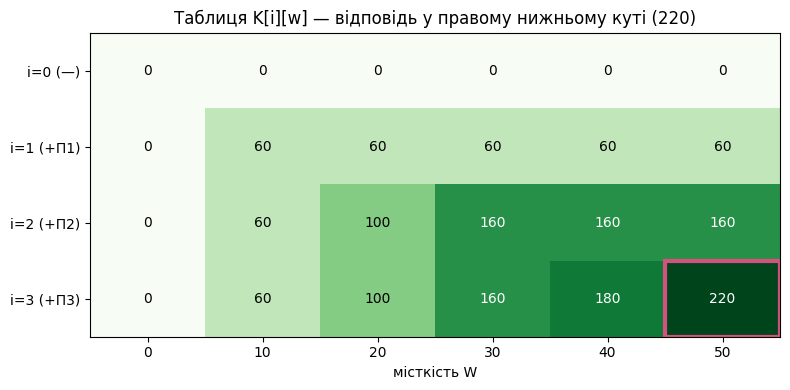

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# зведена таблиця K[i][w] для місткостей 0, 10, 20, 30, 40, 50
caps = [0, 10, 20, 30, 40, 50]
rows = ['i=0 (—)', 'i=1 (+П1)', 'i=2 (+П2)', 'i=3 (+П3)']
K = np.array([
    [0,  0,   0,   0,   0,   0  ],
    [0,  60,  60,  60,  60,  60 ],
    [0,  60,  100, 160, 160, 160],
    [0,  60,  100, 160, 180, 220],
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(K, cmap='Greens', aspect='auto')

ax.set_xticks(range(len(caps)));  ax.set_xticklabels(caps)
ax.set_yticks(range(len(rows)));  ax.set_yticklabels(rows)
ax.set_xlabel('місткість W')
ax.set_title('Таблиця K[i][w] — відповідь у правому нижньому куті (220)')

# числа в клітинках
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        ax.text(j, i, K[i, j], ha='center', va='center',
                color='white' if K[i, j] > 120 else 'black', fontsize=10)

# рамка навколо клітинки-відповіді K[3][50]
ax.add_patch(plt.Rectangle((4.5, 2.5), 1, 1, fill=False,
                           edgecolor='#D4537E', linewidth=3))
plt.tight_layout()
plt.show()

## Переваги та недоліки динамічного програмування

### Переваги
- **Гарантує оптимальний результат** для задачі 0/1.
- **Значно швидший за брутфорс:** складність **O(n·W)** замість O(2ⁿ).
- За таблицею легко відновити, **які саме предмети** входять у відповідь.

### Недоліки
- **Витрати пам’яті — O(n·W)** (можна оптимізувати до O(W) одним рядком).
- Залежить від місткості `W`: якщо ваги/місткість дуже великі або дробові, таблиця стає величезною.
- Складніший для розуміння, ніж жадібний метод.

## Маленький приклад із розбором клітинок

3 предмети, рюкзак на **4** одиниці:
- П1: вага 1, вартість 6
- П2: вага 2, вартість 10
- П3: вага 3, вартість 12

Таблиця `K[i][w]` (i — скільки предметів дозволено, w — місткість):

```
 i \ w |  0   1   2   3   4
-------+--------------------
 0 (—) |  0   0   0   0   0
 1 +П1 |  0   6   6   6   6
 2 +П2 |  0   6  10  16  16
 3 +П3 |  0   6  10  16  18
```

### Розбір по клітинках

**Рядок 0 і стовпець 0** — усюди 0: без предметів або без місця вартість = 0.

**Рядок 1 (дозволено лише П1: вага 1, варт. 6)**
- `K[1][1…4]`: П1 (вага 1) скрізь влазить → взяти 6 краще за 0 → **6** у кожній клітинці.

**Рядок 2 (дозволено П1 і П2: П2 вага 2, варт. 10)**
- `K[2][1] = 6`: П2 (вага 2) не влазить у 1 → беремо зверху → **6**.
- `K[2][2] = 10`: П2 влазить → взяти = 10 + K[1][0] = 10  проти  не брати = 6 → **10**.
- `K[2][3] = 16`: взяти = 10 + K[1][1] = 10 + 6 = 16  проти  не брати = 6 → **16** (це П1 + П2).
- `K[2][4] = 16`: взяти = 10 + K[1][2] = 16  проти  не брати = 6 → **16**.

**Рядок 3 (дозволено всі; П3 вага 3, варт. 12)**
- `K[3][1] = 6`, `K[3][2] = 10`: П3 (вага 3) не влазить → беремо зверху.
- `K[3][3] = 16`: П3 влазить, але взяти = 12 + K[2][0] = 12 **менше** за не брати = 16 → лишаємо **16**. **Цікаво:** предмет влазив, проте вигідніше його НЕ брати (пара П1 + П2 цінніша).
- `K[3][4] = 18`: П3 влазить → взяти = 12 + K[2][1] = 12 + 6 = 18  проти  не брати = 16 → **18**.

**Відповідь — `K[3][4] = 18`**: у рюкзаку П1 + П3 (вага 1 + 3 = 4, вартість 6 + 12 = 18).

## Дуже детальний розбір кожної клітинки

### Спочатку — звідки береться «влазить / не влазить»

Ключ до розуміння: **номер стовпця `w` — це і є місткість рюкзака** в цій підзадачі. Стовпець `w=1` означає «рюкзак, у який влізе лише 1 одиниця ваги», `w=3` — «рюкзак на 3 одиниці».

«Поточний предмет» у рядку `i` — це предмет №`i`. Чи він влазить, перевіряємо порівнянням:

> **вага предмета  ≤  w (номер стовпця)?**

- **Ні** (вага більша за `w`) → не влазить → беремо число з клітинки **прямо над** (найкраще без цього предмета): `K[i−1][w]`.
- **Так** → влазить → беремо `max` із двох:
  - **не брати:** `K[i−1][w]` (значення зверху);
  - **взяти:** `вартість предмета + K[i−1][w − вага]`. Тут `w − вага` — це **залишок місця** після того, як поклали предмет; найкраще для цього залишку вже пораховане в рядку вище.

Предмети: **П1** (вага 1, варт. 6), **П2** (вага 2, варт. 10), **П3** (вага 3, варт. 12).

---

### Рядок i=0 — жодного предмета
`K[0][0…4]` — усі = **0**. Предметів нема, тож і вартості нема.

### Рядок i=1 — дозволено П1 (вага 1, варт. 6)
- `K[1][0]`: місткість 0 → класти нікуди → **0**.
- `K[1][1]`: місткість 1. Влазить П1? **1 ≤ 1 → так**. взяти = 6 + `K[0][1−1]` = 6 + `K[0][0]` = 6 + 0 = 6; не брати = `K[0][1]` = 0. max(6, 0) = **6**.
- `K[1][2]`: місткість 2. **1 ≤ 2 → так**. взяти = 6 + `K[0][1]` = 6; не брати = 0. → **6**.
- `K[1][3]`: місткість 3. **1 ≤ 3 → так**. взяти = 6 + `K[0][2]` = 6; не брати = 0. → **6**.
- `K[1][4]`: місткість 4. **1 ≤ 4 → так**. взяти = 6 + `K[0][3]` = 6; не брати = 0. → **6**.

### Рядок i=2 — дозволено П1 і П2 (П2: вага 2, варт. 10)
- `K[2][0]`: місткість 0 → **0**.
- `K[2][1]`: місткість 1. Влазить П2 (вага 2)? **2 ≤ 1? Ні** (2 більше за 1) → не влазить → беремо зверху `K[1][1]` = **6**.
- `K[2][2]`: місткість 2. **2 ≤ 2 → так**. взяти = 10 + `K[1][2−2]` = 10 + `K[1][0]` = 10 + 0 = 10; не брати = `K[1][2]` = 6. max(10, 6) = **10**.
- `K[2][3]`: місткість 3. **2 ≤ 3 → так**. взяти = 10 + `K[1][3−2]` = 10 + `K[1][1]` = 10 + 6 = 16; не брати = `K[1][3]` = 6. max(16, 6) = **16** (це П1 + П2).
- `K[2][4]`: місткість 4. **2 ≤ 4 → так**. взяти = 10 + `K[1][4−2]` = 10 + `K[1][2]` = 10 + 6 = 16; не брати = `K[1][4]` = 6. max(16, 6) = **16**.

### Рядок i=3 — дозволено всі (П3: вага 3, варт. 12)
- `K[3][0]`: місткість 0 → **0**.
- `K[3][1]`: місткість 1. **3 ≤ 1? Ні** → не влазить → зверху `K[2][1]` = **6**.
- `K[3][2]`: місткість 2. **3 ≤ 2? Ні** → не влазить → зверху `K[2][2]` = **10**.
- `K[3][3]`: місткість 3. **3 ≤ 3 → так**. взяти = 12 + `K[2][3−3]` = 12 + `K[2][0]` = 12 + 0 = 12; не брати = `K[2][3]` = 16. max(12, 16) = **16** → вигідніше НЕ брати П3.
- `K[3][4]`: місткість 4. **3 ≤ 4 → так**. взяти = 12 + `K[2][4−3]` = 12 + `K[2][1]` = 12 + 6 = 18; не брати = `K[2][4]` = 16. max(18, 16) = **18** ← відповідь.

**Відповідь = `K[3][4]` = 18** (П1 + П3).

## Порівняння методів

| Метод            | Відповідь | Складність | Оптимум? |
|------------------|-----------|------------|----------|
| Повний перебір   | 220       | O(2ⁿ)      | ✅ так   |
| Жадібний         | 160       | O(n·log n) | ❌ ні (для 0/1) |
| Динамічне прогр. | 220       | O(n·W)     | ✅ так   |

**Висновок:** брутфорс і ДП дають правильні 220, але ДП робить це набагато ефективніше. Жадібний метод найшвидший, проте для задачі 0/1 може помилятися.

### Пояснення складності словами

**Повний перебір — O(2ⁿ) — експоненційна складність..**
Цей метод перевіряє всі можливі комбінації предметів: брати предмет або не брати. Тому з кожним новим предметом кількість варіантів майже подвоюється. Якщо предметів мало, метод працює нормально, але при великій кількості стає дуже повільним.

**Жадібний метод — O(n·log n) — лінійно-логарифмічна складність..**
Спочатку предмети сортуються за певним критерієм, наприклад за співвідношенням цінності до ваги. Саме сортування займає найбільше часу — O(n·log n). Після цього алгоритм швидко проходить по списку предметів. Тому жадібний метод працює швидко, але для задачі 0/1-рюкзака не завжди знаходить найкращий результат.

**Динамічне програмування — O(n·W) — псевдополіноміальна складність..**
Цей метод поступово будує таблицю рішень для кожного предмета і кожної можливої місткості рюкзака. Тут `n` — кількість предметів, а `W` — максимальна вага рюкзака. ДП працює значно швидше за повний перебір і гарантує оптимальну відповідь, але потребує більше памʼяті для збереження таблиці.


In [ ]:
# Дані задачі
weights = [1, 2, 3]      # ваги предметів П1, П2, П3
values  = [6, 10, 12]    # вартості предметів П1, П2, П3
names   = ["П1", "П2", "П3"]
W = 4                    # місткість рюкзака
n = len(weights)         # кількість предметів

# Таблиця (n+1) x (W+1), заповнена нулями (це базовий рядок i=0)
dp = [[0] * (W + 1) for _ in range(n + 1)]

# Заповнюємо рядок за рядком, починаючи з i = 1
for i in range(1, n + 1):
    wi = weights[i - 1]   # вага поточного предмета
    vi = values[i - 1]    # вартість поточного предмета
    for w in range(W + 1):
        if wi > w:
            dp[i][w] = dp[i - 1][w]                       # не вміщується
        else:
            without_item = dp[i - 1][w]                  # не брати
            with_item    = vi + dp[i - 1][w - wi]        # взяти
            dp[i][w] = max(without_item, with_item)

print("Максимальна вартість:", dp[n][W])   # -> 18

Максимальна вартість: 18


In [ ]:
# Те саме, але з поясненням КОЖНОЇ комірки під час заповнення
dp = [[0] * (W + 1) for _ in range(n + 1)]

for i in range(1, n + 1):
    wi, vi = weights[i - 1], values[i - 1]
    print(f"\n=== Рядок i={i}  ({names[i-1]}: вага={wi}, вартість={vi}) ===")
    for w in range(W + 1):
        if wi > w:
            dp[i][w] = dp[i - 1][w]
            print(f"dp[{i}][{w}]: вага {wi} > {w} -> не вміщується -> "
                  f"беремо згори dp[{i-1}][{w}]={dp[i-1][w]}  =>  {dp[i][w]}")
        else:
            without_item = dp[i - 1][w]
            with_item = vi + dp[i - 1][w - wi]
            dp[i][w] = max(without_item, with_item)
            print(f"dp[{i}][{w}]: вага {wi} <= {w} -> вміщується -> "
                  f"max(не брати={without_item}, "
                  f"взяти {vi}+dp[{i-1}][{w-wi}]={with_item})  =>  {dp[i][w]}")


=== Рядок i=1  (П1: вага=1, вартість=6) ===
dp[1][0]: вага 1 > 0 -> не вміщується -> беремо згори dp[0][0]=0  =>  0
dp[1][1]: вага 1 <= 1 -> вміщується -> max(не брати=0, взяти 6+dp[0][0]=6)  =>  6
dp[1][2]: вага 1 <= 2 -> вміщується -> max(не брати=0, взяти 6+dp[0][1]=6)  =>  6
dp[1][3]: вага 1 <= 3 -> вміщується -> max(не брати=0, взяти 6+dp[0][2]=6)  =>  6
dp[1][4]: вага 1 <= 4 -> вміщується -> max(не брати=0, взяти 6+dp[0][3]=6)  =>  6

=== Рядок i=2  (П2: вага=2, вартість=10) ===
dp[2][0]: вага 2 > 0 -> не вміщується -> беремо згори dp[1][0]=0  =>  0
dp[2][1]: вага 2 > 1 -> не вміщується -> беремо згори dp[1][1]=6  =>  6
dp[2][2]: вага 2 <= 2 -> вміщується -> max(не брати=6, взяти 10+dp[1][0]=10)  =>  10
dp[2][3]: вага 2 <= 3 -> вміщується -> max(не брати=6, взяти 10+dp[1][1]=16)  =>  16
dp[2][4]: вага 2 <= 4 -> вміщується -> max(не брати=6, взяти 10+dp[1][2]=16)  =>  16

=== Рядок i=3  (П3: вага=3, вартість=12) ===
dp[3][0]: вага 3 > 0 -> не вміщується -> беремо згори dp[2][0]=0

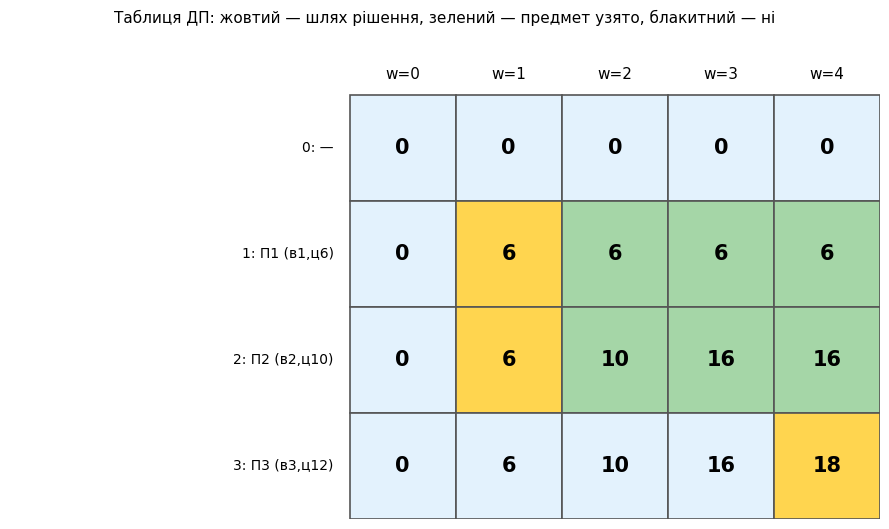

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1) Для кожної комірки визначаємо, чи був предмет узятий (звідки прийшов максимум)
took = [[False] * (W + 1) for _ in range(n + 1)]
for i in range(1, n + 1):
    wi, vi = weights[i - 1], values[i - 1]
    for w in range(W + 1):
        if wi <= w and vi + dp[i - 1][w - wi] > dp[i - 1][w]:
            took[i][w] = True

# 2) Зворотний хід: позначаємо клітинки, через які проходить оптимальне рішення
path = set()
w = W
for i in range(n, 0, -1):
    path.add((i, w))
    if took[i][w]:
        w -= weights[i - 1]

# 3) Малюємо таблицю
fig, ax = plt.subplots(figsize=(9, 5.5))
rows, cols = n + 1, W + 1
row_labels = ["0: —", "1: П1 (в1,ц6)", "2: П2 (в2,ц10)", "3: П3 (в3,ц12)"]

for i in range(rows):
    for w in range(cols):
        y = rows - 1 - i                      # рядок 0 — угорі
        if (i, w) in path:
            color = "#ffd54f"                 # шлях рішення
        elif took[i][w]:
            color = "#a5d6a7"                 # предмет узято
        else:
            color = "#e3f2fd"                 # не взято / не вміщується
        ax.add_patch(Rectangle((w, y), 1, 1, facecolor=color,
                               edgecolor="#555", linewidth=1.2))
        ax.text(w + 0.5, y + 0.5, str(dp[i][w]),
                ha="center", va="center", fontsize=15, fontweight="bold")

for w in range(cols):                         # підписи стовпців
    ax.text(w + 0.5, rows + 0.12, f"w={w}", ha="center", va="bottom", fontsize=11)
for i in range(rows):                         # підписи рядків
    ax.text(-0.15, rows - 1 - i + 0.5, row_labels[i], ha="right", va="center", fontsize=10)

ax.set_xlim(-3.2, cols)
ax.set_ylim(0, rows + 0.6)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Таблиця ДП: жовтий — шлях рішення, зелений — предмет узято, "
             "блакитний — ні", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Зворотний хід: відновлюємо набір предметів
w = W
chosen = []
for i in range(n, 0, -1):
    if dp[i][w] != dp[i - 1][w]:      # значення змінилось -> предмет i був узятий
        chosen.append(names[i - 1])
        w -= weights[i - 1]           # звільняємо вагу, яку зайняв предмет

chosen.reverse()
print("Обрані предмети:", chosen)                    # -> ['П1', 'П3']
print("Сумарна вага:   ", sum(weights[names.index(c)] for c in chosen))  # -> 4
print("Сумарна вартість:", dp[n][W])                 # -> 18

Обрані предмети: ['П1', 'П3']
Сумарна вага:    4
Сумарна вартість: 18


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'   # коректна кирилиця

# Потрібні дані з попередніх комірок: weights, values, names, W, n, dp
ROW_LABELS = ["0: —", "1: П1 (в1,ц6)", "2: П2 (в2,ц10)", "3: П3 (в3,ц12)"]

def _c(r, col, rows):
    return (col + 0.5, rows - 1 - r + 0.5)

def draw_cell(i, w):
    """Графічно показує, як рахується одна комірка dp[i][w]."""
    rows, cols = n + 1, W + 1
    wi, vi = weights[i-1], values[i-1]
    fits = wi <= w
    if fits:
        without_item = dp[i-1][w]               # не брати
        with_item    = vi + dp[i-1][w - wi]     # взяти
        result, took = max(without_item, with_item), with_item > without_item
    else:
        result = dp[i-1][w]

    fig, ax = plt.subplots(figsize=(8.6, 6.4))
    computed = lambda r, col: (r < i) or (r == i and col < w)

    for r in range(rows):
        for col in range(cols):
            y = rows - 1 - r
            face, edge, lw, txt, tc = "#f7f7f7", "#dddddd", 1.0, "", "#999"
            if r == i and col == w:                              # поточна
                face, edge, lw, txt, tc = "#ffcdd2", "#c62828", 2.8, str(result), "#b71c1c"
            elif fits and r == i-1 and col == w - wi:            # джерело «взяти»
                face, edge, lw, txt, tc = "#a5d6a7", "#2e7d32", 2.2, str(dp[r][col]), "#1b5e20"
            elif r == i-1 and col == w:                          # джерело «не брати»
                face, edge, lw, txt, tc = "#90caf9", "#1565c0", 2.2, str(dp[r][col]), "#0d47a1"
            elif computed(r, col):                               # вже відомі
                face, edge, txt, tc = "#ffffff", "#bdbdbd", str(dp[r][col]), "#424242"
            ax.add_patch(Rectangle((col, y), 1, 1, facecolor=face, edgecolor=edge, linewidth=lw))
            if txt:
                ax.text(col+0.5, y+0.5, txt, ha="center", va="center",
                        fontsize=16, fontweight="bold", color=tc)

    cur = _c(i, w, rows)
    ax.annotate("", xy=cur, xytext=_c(i-1, w, rows),
                arrowprops=dict(arrowstyle="-|>", color="#1565c0", lw=2.4, shrinkA=17, shrinkB=17))
    if fits and (w - wi) != w:
        ax.annotate("", xy=cur, xytext=_c(i-1, w - wi, rows),
                    arrowprops=dict(arrowstyle="-|>", color="#2e7d32", lw=2.4, shrinkA=17, shrinkB=17,
                                    connectionstyle="arc3,rad=0.18"))

    for col in range(cols):
        ax.text(col+0.5, rows+0.12, f"w={col}", ha="center", va="bottom", fontsize=10, color="#555")
    for r in range(rows):
        ax.text(-0.15, rows-1-r+0.5, ROW_LABELS[r], ha="right", va="center", fontsize=9.5, color="#555")

    if fits:
        formula = (f"Вага П{i} = {wi}  ≤  w = {w}   → вміщується\n\n"
                   f"не брати : dp[{i-1}][{w}] = {without_item}{'   ← перемагає' if not took else ''}\n"
                   f"взяти    : {vi} + dp[{i-1}][{w-wi}] = {vi}+{dp[i-1][w-wi]} = {with_item}"
                   f"{'   ← перемагає' if took else ''}\n\n"
                   f"dp[{i}][{w}] = max({without_item}, {with_item}) = {result}")
        box = "#e8f5e9"
    else:
        formula = (f"Вага П{i} = {wi}  >  w = {w}\n"
                   f"→ предмет НЕ вміщується\n"
                   f"→ копіюємо значення згори\n\n"
                   f"dp[{i}][{w}] = dp[{i-1}][{w}] = {result}")
        box = "#fff3e0"
    ax.text(-3.3, -0.5, formula, ha="left", va="top", fontsize=11, family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor=box, edgecolor="#888"))

    leg = ("червоний — поточна комірка\n"
           "синій   — джерело «не брати»\n"
           "зелений — джерело «взяти»")
    ax.text(cols+0.25, rows-0.3, leg, ha="left", va="top", fontsize=8.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#fafafa", edgecolor="#ccc"))

    ax.set_xlim(-3.5, cols+3.2); ax.set_ylim(-2.9, rows+0.7)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"Заповнення комірки  dp[{i}][{w}]   (предмет П{i},  місткість w={w})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

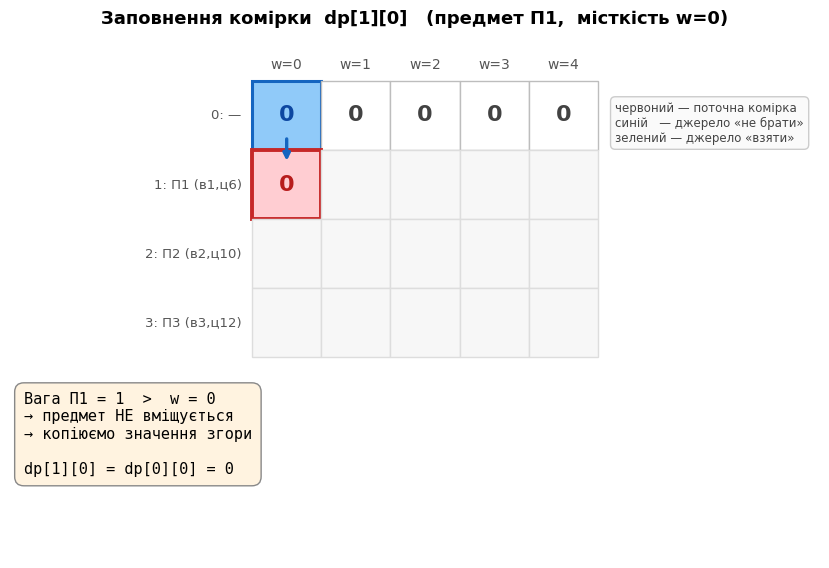

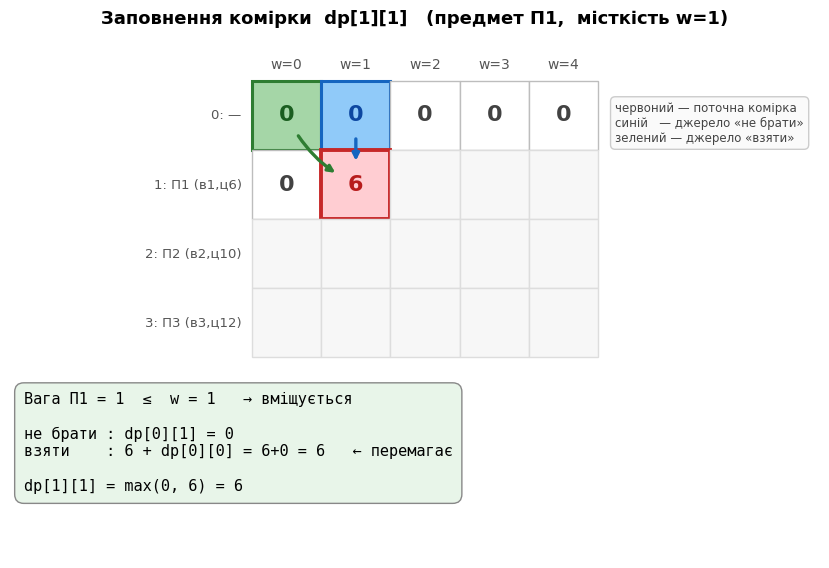

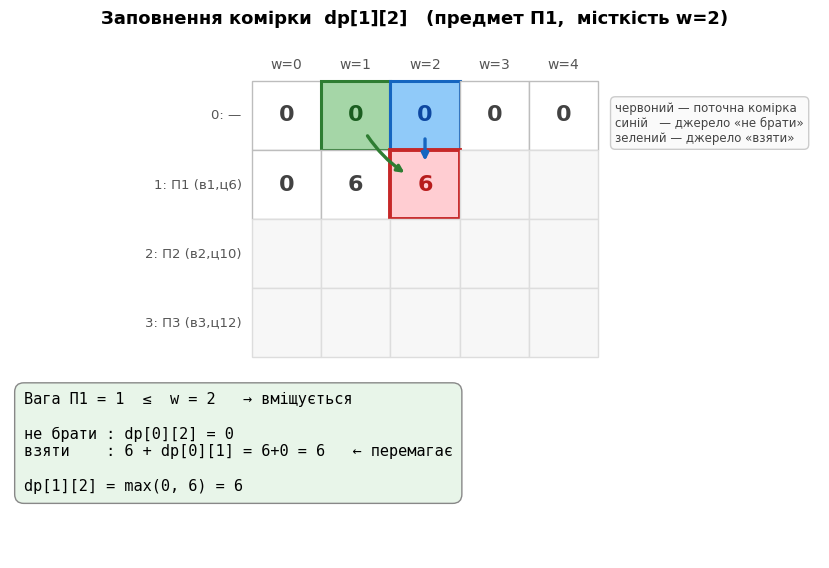

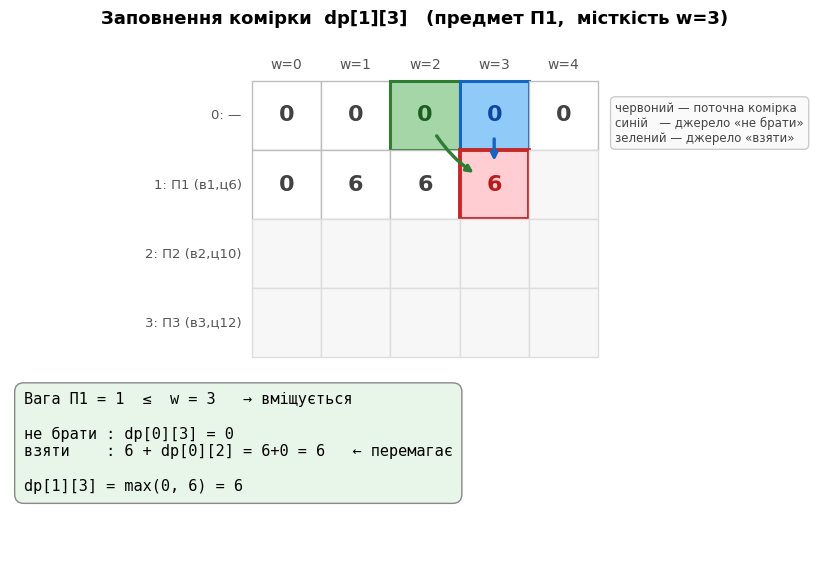

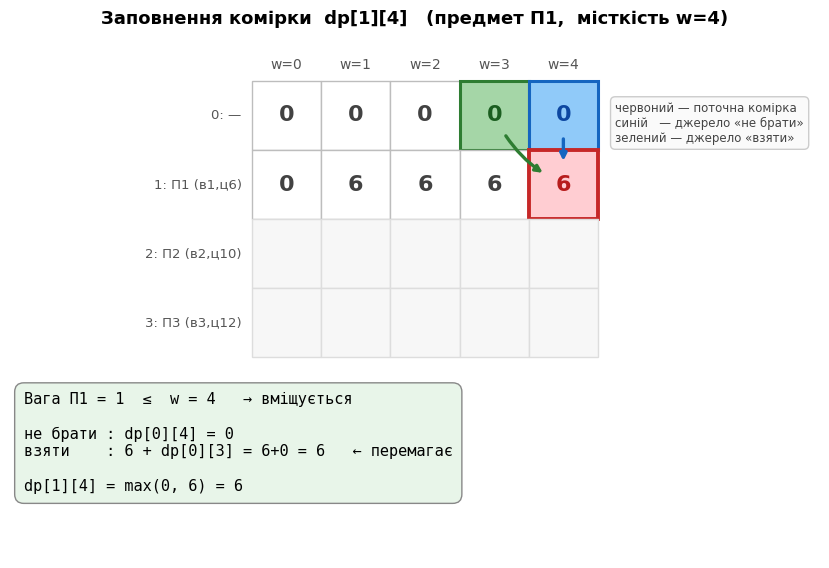

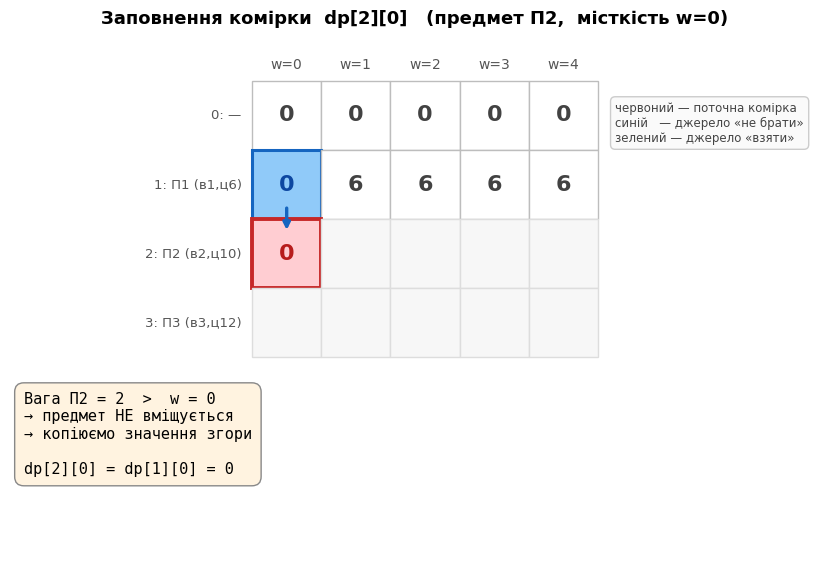

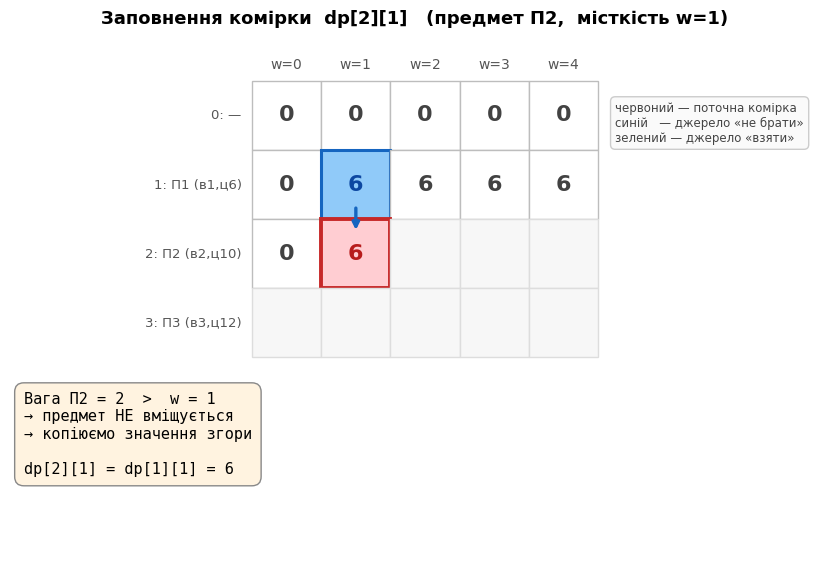

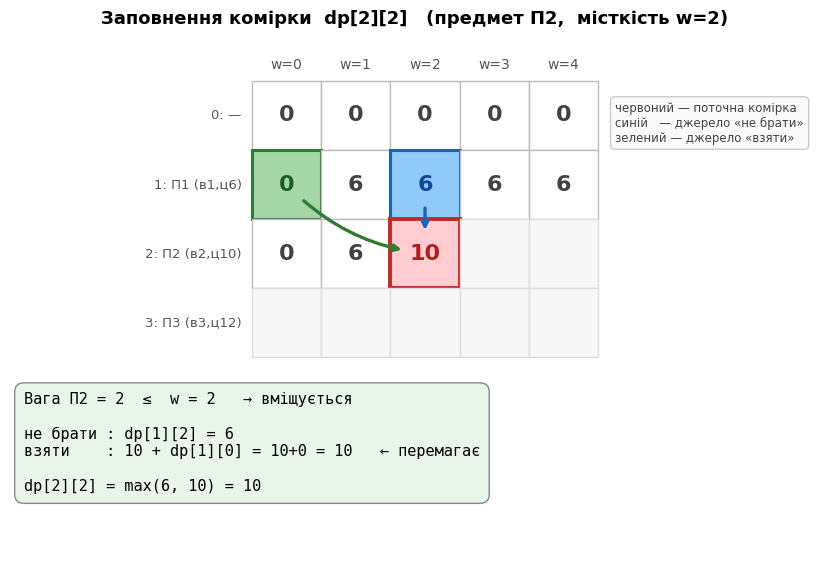

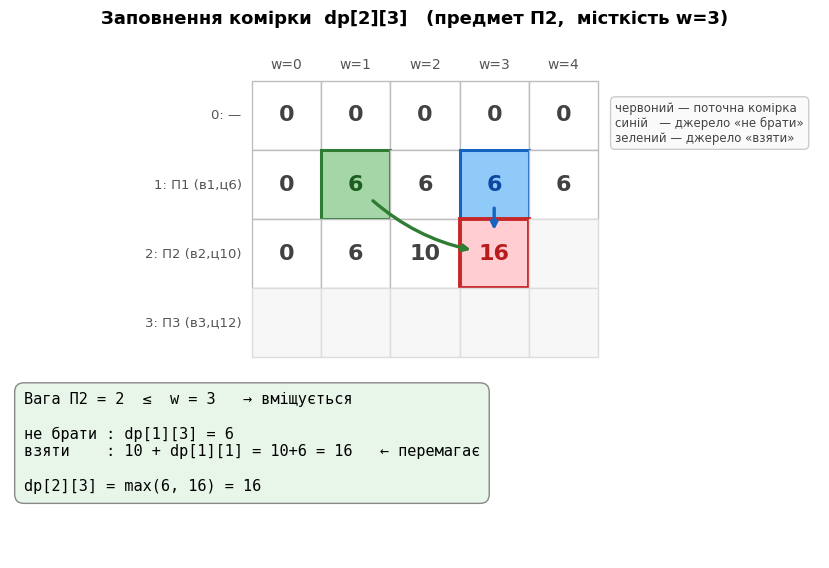

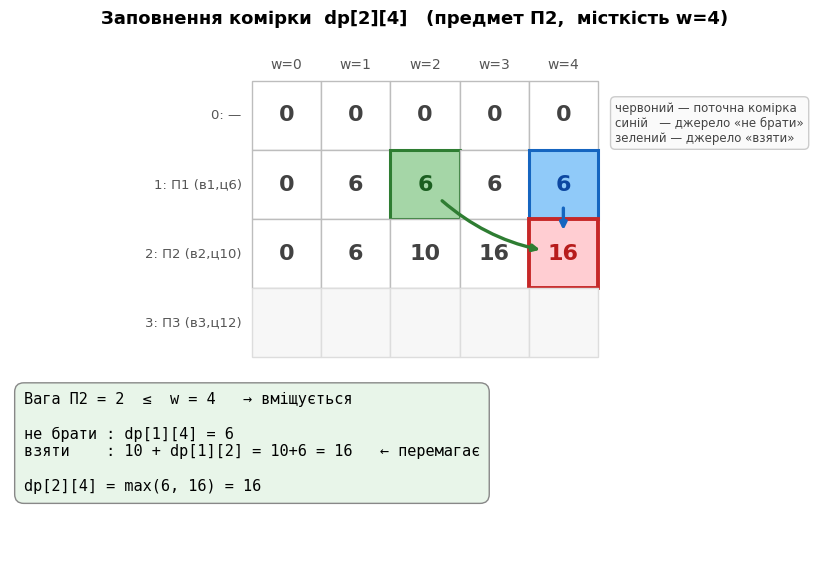

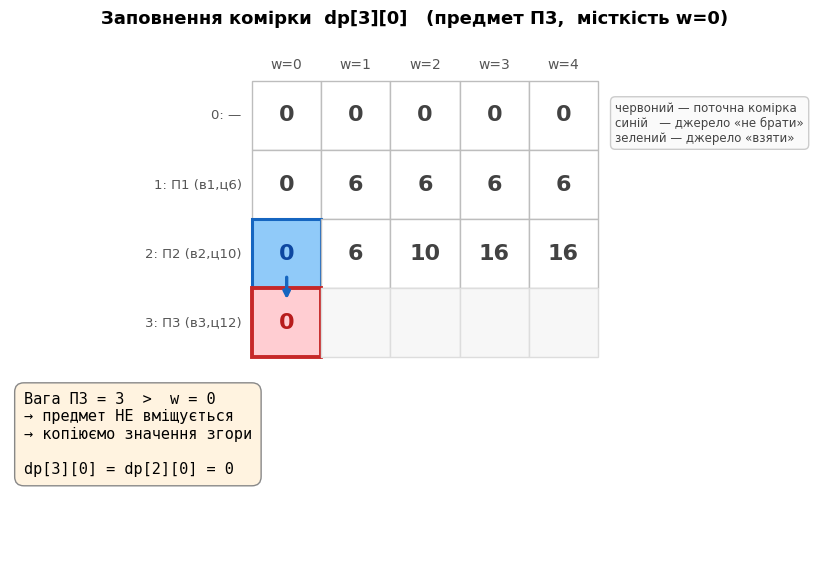

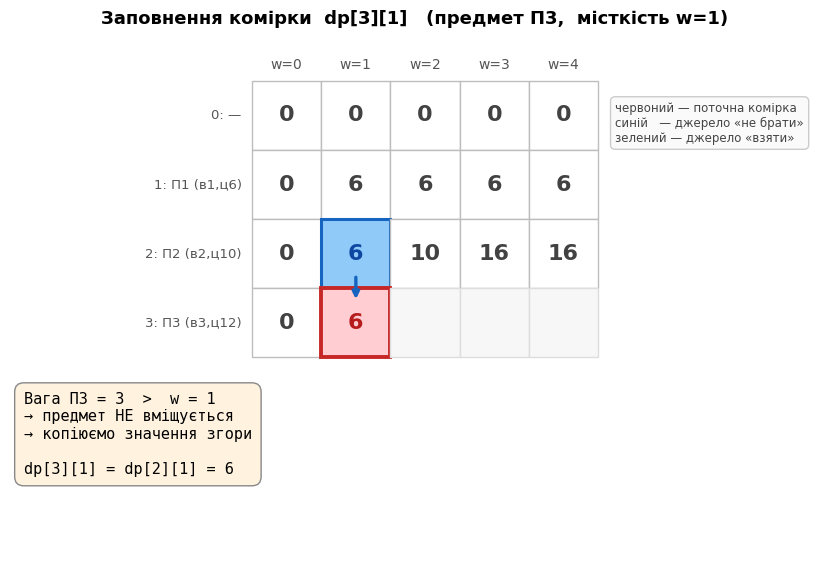

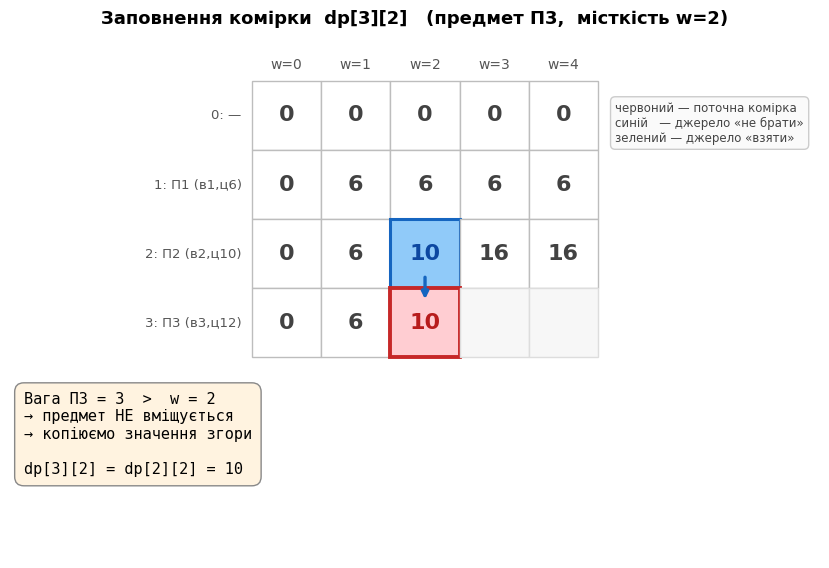

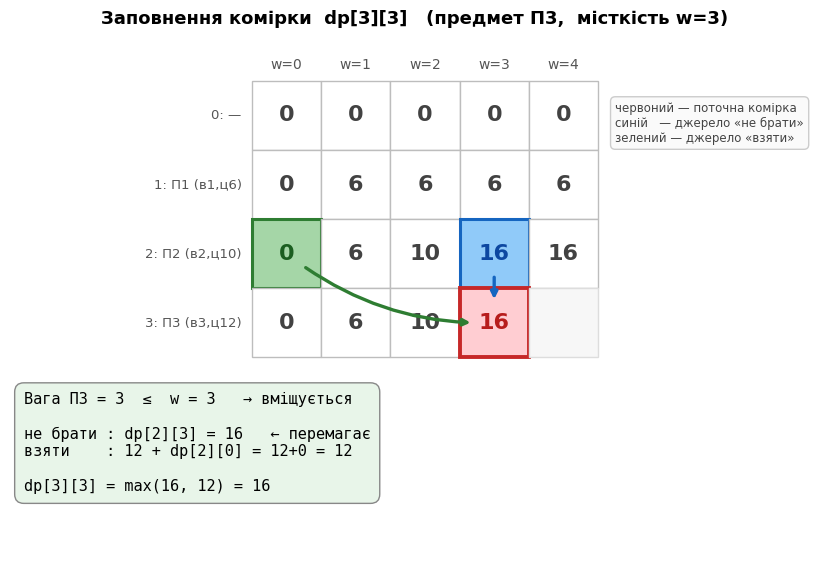

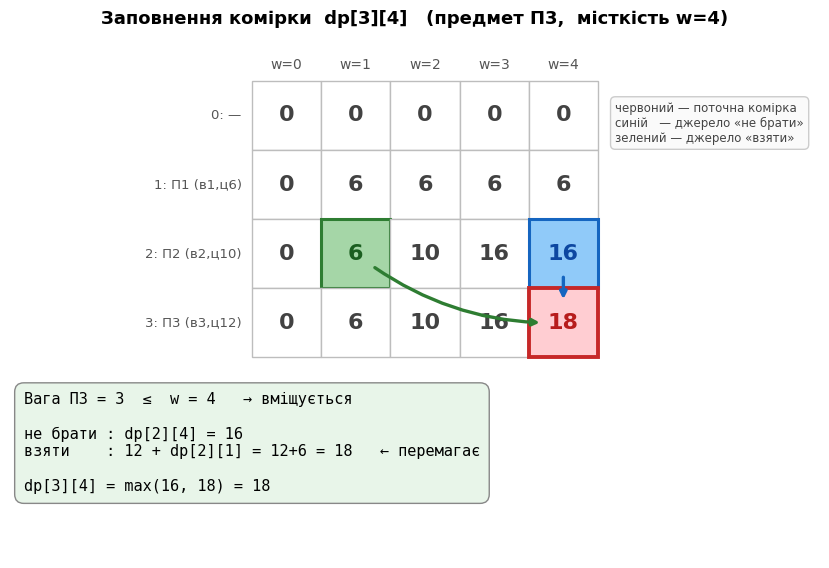

In [ ]:
# Графік на КОЖНУ комірку, що реально обчислюється (рядки 1..3).
# Рядок 0 — базовий (усі нулі), його не рахуємо.
for i in range(1, n + 1):
    for w in range(W + 1):
        draw_cell(i, w)